# Autoassociation network
AKA *Autoassociative memory* 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(1234)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams["figure.figsize"] = [16, 9]

### Handy utility functions

In [2]:
def append_ones(matrix: np.ndarray, axis: int = 1) -> np.ndarray:
    """
    Appends a column of ones to the right side of a 2D matrix.
    """
    return np.concatenate(
        (matrix, np.ones((matrix.shape[0], 1), dtype=np.float32)), axis=axis
    )


def zeros(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of zeros with the given shape.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. zeros(3, 4) creates a (3, 4) array.
    """
    return np.zeros(shape=tuple(dims), dtype=np.float32)


def ones(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of ones with the given shape.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. ones(3, 4) creates a (3, 4) array.
    """
    return np.ones(shape=tuple(dims), dtype=np.float32)


def rand(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of random values sampled from a uniform [0, 1) distribution.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. rand(3, 4) creates a (3, 4) array.
    """
    return np.random.rand(*dims).astype(np.float32)


def randn(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of random values sampled from a standard normal distribution.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. rand(3, 4) creates a (3, 4) array.
    """
    return np.random.randn(*dims).astype(np.float32)


def chunks(seq: list, size: int) -> tuple[np.ndarray]:
    """
    Splits a sequence into consecutive chunks of a given size.

    The last chunk may be smaller than `size` if the sequence length
    is not evenly divisible.

    Args:
        seq:  The input sequence (e.g. list or other sliceable) to split.
        size: The maximum number of elements in each chunk.

    Returns:
        Successive sub-sequences of length `size` (or less for the final chunk).
    """
    return tuple([seq[pos : (pos + size)] for pos in range(0, len(seq), size)])


def as_matrix(vector: np.ndarray) -> np.ndarray:
    """Reshape 1D vector to column matrix."""
    return np.reshape(vector, (-1, 1))


def arrange_tiles_img(examples: np.ndarray) -> np.ndarray:
    """
    Arrange 2D matrices as tiles

    Takes 4D `examples` tensor with dims:
        rows x cols x tile_height x tile_width
    """
    rows_count = examples.shape[0]
    cols_count = examples.shape[1]
    tile_height = examples.shape[2]
    tile_width = examples.shape[3]

    space_between_tiles = 2
    img_matrix = np.empty(
        shape=(
            rows_count * (tile_height + space_between_tiles) - space_between_tiles,
            cols_count * (tile_width + space_between_tiles) - space_between_tiles,
        )
    )
    img_matrix.fill(np.nan)

    for r in range(rows_count):
        for c in range(cols_count):
            x_0 = r * (tile_height + space_between_tiles)
            y_0 = c * (tile_width + space_between_tiles)
            img_matrix[x_0 : x_0 + tile_height, y_0 : y_0 + tile_width] = examples[r, c]

    return img_matrix


def preview_tiles(examples: np.ndarray) -> None:
    """Previews the arrange tiles"""
    img = arrange_tiles_img(examples)
    plt.matshow(img, cmap="gray", interpolation="none")
    plt.axis("off")
    plt.show()


def draw_rbm_filters(rbm: "RestrictedBoltzmannMachine") -> None:
    filters = np.reshape(np.transpose(rbm.W)[:-1, :-1], newshape=(8, -1, 28, 28))
    preview_tiles(filters)


def draw_layer_filters(layer: "Layer") -> None:
    filters = np.reshape(layer.W[:-1].T, newshape=(8, -1, 28, 28))
    preview_tiles(filters)

### Activation functions

In [3]:
def sigmoid(batch: np.ndarray, stochastic: bool = False) -> np.ndarray:
    activations = 1.0 / (1.0 + np.exp(-batch))
    if stochastic:
        return activations > rand(*activations.shape).astype(np.float32)
    else:
        return activations


def sigmoid_derivative(batch: np.ndarray) -> np.ndarray:
    s = sigmoid(batch)
    return s * (1.0 - s)

In [4]:
# Tip: its a plain linear function with optional stochastic noise
def gaussian(batch: np.ndarray, stochastic: bool = False) -> np.ndarray:
    if stochastic:
        noise = randn(*batch.shape)
        return batch + noise
    return batch


def gaussian_derivative(batch: np.ndarray) -> np.ndarray:
    # TODO implement
    return ones(*batch.shape)

# MNIST dataset

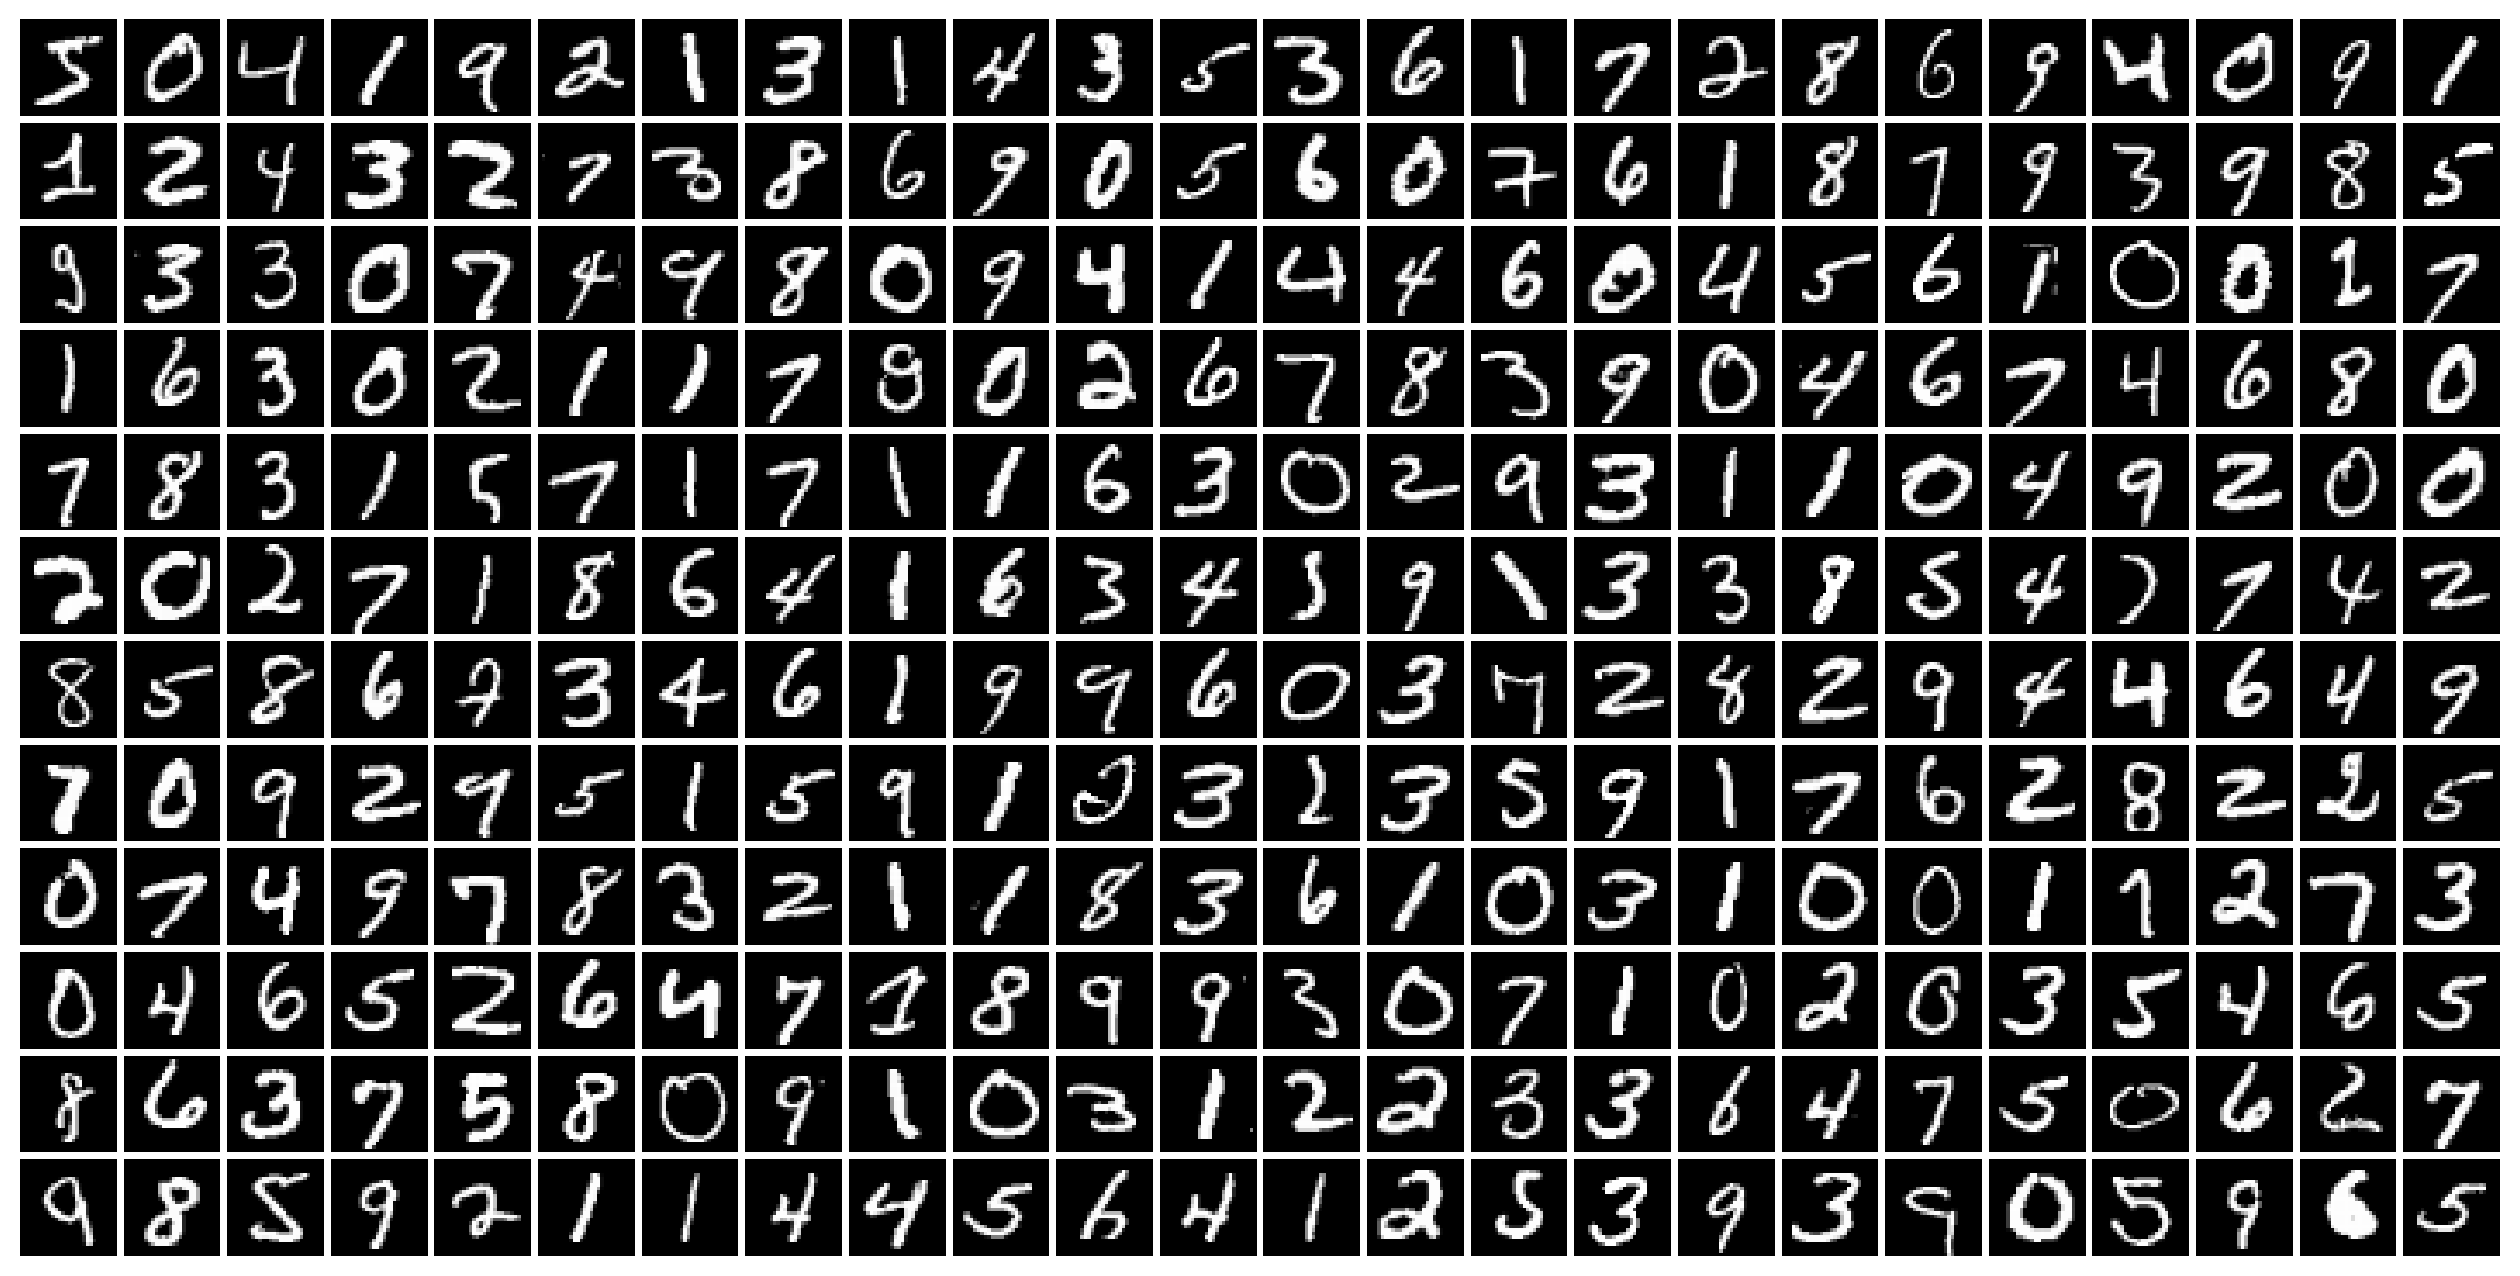

In [5]:
from mnists import MNIST

mnist = MNIST()

PREVIEW_N_ROWS = 12
PREVIEW_N_COLS = 24
TILE_DIM = 28  # [px]


def create_mnist_digits(n_rows: int, n_cols: int, tile_dim: int) -> np.ndarray:
    shape = (n_rows, n_cols, tile_dim, tile_dim)
    return np.reshape(mnist.train_images()[: 12 * 24], newshape=shape)


mnist_digits = create_mnist_digits(PREVIEW_N_ROWS, PREVIEW_N_COLS, TILE_DIM)

preview_tiles(mnist_digits)

# RBM & DBN training

In [6]:
class RestrictedBoltzmannMachine:
    """
    A Restricted Boltzmann Machine (RBM) with a single visible and hidden layer.

    The weight matrix W has shape (visible_size + 1, hidden_size + 1), where
    the extra row and column are reserved for bias units.

    Attributes:
        visible_size:       Number of visible (input) units, excluding the bias.
        hidden_size:        Number of hidden units, excluding the bias.
        visible_act_func:   The activation function used within visible layer.
        hidden_act_func:    The activation function used within hidden layer.
        learning_rate:      Step size used during contrastive divergence updates.
        W:                  Weight matrix of shape (visible_size+1, hidden_size+1).
        momentum:           Momentum coefficient.
        l2_penalty:         Coefficent for the L2 regularization.
    """

    def __init__(
        self,
        visible_size: int,
        hidden_size: int,
        visible_act_func: callable,
        hidden_act_func: callable,
        learning_rate: float,
        momentum: float,
        l2_penalty: float,
    ):
        self.visible_size = visible_size
        self.hidden_size = hidden_size

        self.visible_act_func = visible_act_func
        self.hidden_act_func = hidden_act_func

        self.learning_rate = learning_rate
        self.momentum = momentum

        self.l2_penalty = l2_penalty

        self.reset()

    def reset(self) -> None:
        self.W = np.random.normal(
            scale=0.01, size=(self.visible_size + 1, self.hidden_size + 1)
        ).astype(np.float32)
        self.W[:, -1] = 0.0  # zero hidden-bias weights
        self.W[-1, :] = 0.0  # zero visible-bias weights
        self.M = zeros(self.visible_size + 1, self.hidden_size + 1)

In [7]:
from typing import TypeAlias

DBN: TypeAlias = list[RestrictedBoltzmannMachine]

In [8]:
def cdk(rbm: RestrictedBoltzmannMachine, minibatch: np.ndarray, k: int = 1) -> None:
    observations_count = minibatch.shape[0]

    positive_visible = minibatch
    negative_visible = append_ones(zeros(observations_count, rbm.visible_size))

    positive_hidden = append_ones(zeros(observations_count, rbm.hidden_size))
    negative_hidden = append_ones(zeros(observations_count, rbm.hidden_size))

    z = minibatch @ rbm.W[:, :-1]
    positive_hidden[:, :-1] = rbm.hidden_act_func(z)
    negative_hidden[:, :-1] = rbm.hidden_act_func(z, stochastic=True)

    for cd_i in range(k):
        negative_visible[:, :-1] = rbm.visible_act_func(
            negative_hidden @ rbm.W[:-1, :].T, stochastic=True
        )
        z = negative_visible @ rbm.W[:, :-1]
        if cd_i < (k - 1):
            negative_hidden[:, :-1] = rbm.hidden_act_func(z, stochastic=True)
        else:
            negative_hidden[:, :-1] = rbm.hidden_act_func(z)

    rbm.M *= rbm.momentum
    rbm.M += (
        (rbm.learning_rate / observations_count) * positive_visible.T @ positive_hidden
    )
    rbm.M -= (
        (rbm.learning_rate / observations_count) * negative_visible.T @ negative_hidden
    )

    if rbm.l2_penalty is not None:
        rbm.M[:-1, :-1] = (
            rbm.M[:-1, :-1] - rbm.learning_rate * rbm.l2_penalty * rbm.W[:-1, :-1]
        )

    rbm.W += rbm.M


def reconstruction_error(
    rbm: RestrictedBoltzmannMachine, minibatch: np.ndarray
) -> float:
    """
    Computes the mean per-sample reconstruction error on a minibatch.
    """
    observations_count = minibatch.shape[0]
    visible = zeros(observations_count, rbm.visible_size)
    hidden = append_ones(zeros(observations_count, rbm.hidden_size))

    hidden[:, :-1] = rbm.hidden_act_func(minibatch @ rbm.W[:, :-1])
    hidden[:, :-1] = hidden[:, :-1] > rand(observations_count, rbm.hidden_size)

    visible = rbm.visible_act_func(hidden @ np.transpose(rbm.W[:-1, :]))

    error = minibatch[:, :-1] - visible
    return np.sum(np.square(error)) / observations_count

In [9]:
def propagate_up(
    dbn: DBN,
    layers_count: int,
    visible: np.ndarray,
) -> np.ndarray:
    """
    Forward pass through DBN layers: propagates visible units upward to the target layer.
    Appends bias term (ones) and applies sigmoid activation after matrix multiplication.
    """
    for i in range(layers_count):
        visible = append_ones(dbn[i].visible_act_func(visible @ dbn[i].W[:, :-1]))
    return visible


def propagate_down(
    dbn: DBN,
    layers_count: int,
    hidden: np.ndarray,
) -> np.ndarray:
    """
    Reconstruct data by propagating downward through the DBN.
    Appends bias term (ones) and applies sigmoid activation after matrix multiplication.
    """
    for i in reversed(range(layers_count)):
        hidden = append_ones(
            dbn[i].hidden_act_func(hidden @ np.transpose(dbn[i].W[:-1, :]))
        )
    return hidden


def dbn_reconstuction_error(
    dbn: DBN,
    layer_idx: int,
    minibatch: np.ndarray,
) -> float:
    """
    Compute the reconstruction error for a selected DBN layer.

    The minibatch is first propagated upward to the chosen layer,
    then the reconstruction error is evaluated for that RBM.

    Args:
        dbn: List of pretrained RBM layers.
        layer_idx: Index of the RBM layer to evaluate.
        minibatch: Input minibatch.

    Returns:
        Reconstruction error as a scalar value.
    """
    propagated = propagate_up(dbn, layer_idx, minibatch)
    return reconstruction_error(dbn[layer_idx], propagated)


def train_dbn_layer(
    dbn: DBN,
    layer_idx: int,
    dataset: np.ndarray,
    batch_size: int,
) -> None:
    """
    Train one DBN layer using greedy layer-wise pretraining.

    The dataset is first propagated through all previously trained layers.
    Then the selected RBM layer is trained on minibatches.

    Args:
        dbn: List of RBM layers.
        layer_idx: Index of the RBM layer to train.
        dataset: Full training dataset.
        batch_size: Minibatch size.
    """

    dataset = propagate_up(dbn, layer_idx, dataset)

    batches_limit = dataset.shape[0] / batch_size
    for batch_idx, batch in enumerate(chunks(dataset, batch_size)):
        cdk(dbn[layer_idx], batch)
        if batch_idx % round(batches_limit / 50) == 0:
            print("#", end="")


def run_dbn_training(
    dbn: DBN,
    dataset: np.ndarray,
    monitoring_set: np.ndarray,
    batch_size: int,
    epochs_count: int,
    target_momentum: float = 0.9,
) -> None:
    for layer_idx in range(len(dbn)):
        print(f"\nLearning layer {layer_idx}")

        for epoch in range(epochs_count):
            print(f"Epoch {epoch}:", end="\t")

            if epoch == 5:
                dbn[layer_idx].momentum = target_momentum

            start_time = time.time()
            train_dbn_layer(dbn, layer_idx, dataset, batch_size)
            elapsed = time.time() - start_time

            error = dbn_reconstuction_error(dbn, layer_idx, monitoring_set)
            print(f"\telapsed: {elapsed:>2.2f}s, reconstruction error: {error:>2.2f}")

# Autoencoder training

In [10]:
class Layer:
    def __init__(
        self,
        visible_size: int,
        hidden_size: int,
        activation_fun,
        d_activation_fun,
        learning_rate: float,
        momentum: float,
        l2_penalty: float,
    ):
        self.visible_size = visible_size
        self.hidden_size = hidden_size

        self.activation_fun = activation_fun
        self.d_activation_fun = d_activation_fun

        self.learning_rate = learning_rate
        self.momentum = momentum

        self.l2_penalty = l2_penalty

        self.reset()

    def reset(self) -> None:
        self.W = np.random.normal(
            scale=0.01, size=(self.visible_size + 1, self.hidden_size)
        ).astype(np.float32)
        self.W[-1, :] = 0.0  # biases

        self.activations = None
        self.d_activations = None
        self.deltas = None

        self.M = zeros(self.visible_size + 1, self.hidden_size)

In [11]:
from typing import TypeAlias

MLP: TypeAlias = list[Layer]

In [12]:
def forward_pass(ae: MLP, batch: np.ndarray, compute_derivatives: bool) -> np.ndarray:
    visible = batch

    for layer_idx, layer in enumerate(ae):
        z = visible @ layer.W
        layer.activations = append_ones(layer.activation_fun(z))

        if compute_derivatives and (layer_idx < len(ae) - 1):
            layer.d_activations = layer.d_activation_fun(z)

        visible = layer.activations

    return visible[:, :-1]


def error_backpropagate(ae: MLP, batch: np.ndarray) -> None:
    observations_count = batch.shape[0]

    for layer_idx, layer in reversed(list(enumerate(ae))):
        if layer_idx > 0:
            prev_layer = ae[layer_idx - 1]
            visible = prev_layer.activations

            prev_layer.deltas = (
                layer.deltas @ layer.W[:-1, :].T
            ) * prev_layer.d_activations
        else:
            visible = batch

        layer.M *= layer.momentum
        layer.M -= (layer.learning_rate / observations_count) * (
            visible.T @ layer.deltas
        )

        if layer.l2_penalty > 0:
            layer.M[:-1, :] = (
                layer.M[:-1, :]
                - layer.learning_rate * layer.l2_penalty * layer.W[:-1, :]
            )

        layer.W += layer.M

### Cross entropy cost

Implement [cross entropy](https://en.wikipedia.org/wiki/Cross-entropy#Cross-entropy_minimization) cost for deep AE. To this end:
* calculate the cross entropy cost between pixels in the input batch and their reconstructions,
* sum the cross entropy cost over all pixels and all observations in the minibatch,
* return average cost per input observation.

In other words, for each sample in batch, we are trying to implement:
$$
H(p,q) = - \sum_m{p_{m} \log{q_m}}
$$
where $H(p,q)$ is the cross-entropy of the distribution $q$ relative to a distribition $p$ over a given set, where distributions $p \in \{y, 1-y\}$ and $q \in \{ \hat{y}, 1 - \hat{y} \}$ consist of $y$, which is an orignal sample from Mnist, and $\hat{y}$, which is a reconstruction.

In [13]:
def xentropy(batch: np.ndarray, reconstructions: np.ndarray) -> np.ndarray:
    observations_count = batch.shape[0]

    xe = batch * np.log(reconstructions) + (ones(*batch.shape) - batch) * np.log(ones(*reconstructions.shape) - reconstructions)
    xe = -np.sum(xe, axis = 1)
    return np.sum(xe, axis=0) / observations_count

### Training procedure

In [14]:
def train_ae(ae: MLP, dataset: np.ndarray, batch_size: np.ndarray) -> None:
    batches_limit = dataset.shape[0] / batch_size
    batched_data = chunks(dataset, batch_size)

    for batch_idx, batch in enumerate(batched_data):
        reconstructions = forward_pass(ae, batch, True)

        ae[-1].deltas = reconstructions - batch[:, :-1]

        error_backpropagate(ae, batch)

        if batch_idx % round(batches_limit / 40) == 0:
            print("#", end="")

In [15]:
def run_ae_training(
    ae: MLP,
    train_set: np.ndarray,
    validation_set: np.ndarray,
    batch_size: int,
    epochs_count: int,
) -> None:
    for epoch in range(epochs_count):
        print(f"Epoch {epoch + 1}:", end="\t")

        start_time = time.time()
        train_ae(ae, train_set, batch_size)
        elapsed = time.time() - start_time

        xe = xentropy(validation_set[:, :-1], forward_pass(ae, validation_set, False))
        print(f"\telapsed: {elapsed:>2.2f}s, cross-entropy: {xe:>2.2f}")

    print("Training finished!")

###  Initializing AE with DBN weights

Implement initialization of AE weights (and biases) using weights (and biases) from the DBN layers.

Make sure that the AE weights (and biases) are **copies** of the DBN weights (and biases). You can use ```np.copy(...)``` function to copy the weights (simple assignment will make a view instead of a copy).

In [16]:
def initialize_ae_from_dbn(ae: MLP, dbn: DBN) -> None:
    assert len(ae) == 2 * len(dbn)

    n = len(dbn)
    for layer_idx in range(n):
        ae[layer_idx].W = np.copy(dbn[layer_idx].W[:, :-1])
        ae[n + layer_idx].W = np.copy(dbn[n - layer_idx - 1].W[:-1, :].T)

# Autoencoder for MNIST digits

In [17]:
np.random.seed(1234)

DATASET_SIZE: int = 10000  # 60000 for whole dataset
DIGIT_SIZE: int = 28

##### Train set #####

mnist_train_images = mnist.train_images().astype(np.float32) / 255.0
mnist_train_images = np.random.permutation(mnist_train_images)

mnist_train_images = np.reshape(
    mnist_train_images[:DATASET_SIZE], newshape=(DATASET_SIZE, DIGIT_SIZE * DIGIT_SIZE)
)
mnist_train_images = append_ones(mnist_train_images)

monitoring_set_indeces = np.random.choice(
    mnist_train_images.shape[0], 512, replace=False
)
monitoring_set = mnist_train_images[monitoring_set_indeces]

##### Test set #####

mnist_test_images = mnist.test_images().astype(np.float32) / 255.0
mnist_test_images = np.reshape(mnist_test_images, newshape=(-1, DIGIT_SIZE * DIGIT_SIZE))
mnist_test_images = append_ones(mnist_test_images)

In [18]:
VISIBLE_LAYER_SIZE: int = DIGIT_SIZE * DIGIT_SIZE

BATCH_SIZE: int = 128
EPOCHS_COUNT: int = 50

RBM_LEARNING_RATE: float = 0.1
AE_LEARNING_RATE: float = 0.01
AE_MOMENTUM: float = 0.9
L2_PENALTY: float = 0.0002

In [19]:
from IPython.core.display import HTML


def compare_results(
    ae: MLP,
    dbn: DBN,
    train_set: np.ndarray,
    validation_set: np.ndarray,
    monitoring_set: np.ndarray,
    batch_size: int,
    epochs_count: int,
) -> None:
    for layer in ae:
        layer.reset()

    display(HTML("<h3>Plain AE training</h3>"))
    run_ae_training(
        ae=ae,
        train_set=train_set,
        validation_set=validation_set,
        batch_size=batch_size,
        epochs_count=epochs_count,
    )

    display(HTML("<h3>Input layer filters in the plain AE</h3>"))
    draw_layer_filters(ae[0])

    display(HTML("<h3>Input minibatch</h3>"))
    preview_tiles(np.reshape(validation_set[: 8 * 24, :-1], newshape=(8, 24, 28, 28)))

    display(HTML("<h3>Plain AE reconstructions</h3>"))
    ae_reconstructions = np.reshape(
        forward_pass(ae, validation_set[: 8 * 24], False), newshape=(8, 24, 28, 28)
    )
    preview_tiles(ae_reconstructions)

    display(HTML("<h3>DBN training</h3>"))
    run_dbn_training(
        dbn=dbn,
        dataset=train_set,
        monitoring_set=monitoring_set,
        batch_size=batch_size,
        epochs_count=epochs_count,
    )

    for layer in ae:
        layer.reset()

    initialize_ae_from_dbn(ae=ae, dbn=dbn)
    dbn_reconstructions = np.reshape(
        forward_pass(ae, validation_set[: 8 * 24, :], False), newshape=(8, 24, 28, 28)
    )
    dbn_rec_cost = xentropy(
        batch=validation_set[:, :-1],
        reconstructions=forward_pass(ae, validation_set, False),
    )

    display(HTML("<h3>Finetuning pretrained AE</h3>"))

    print("Reconstruction cost before finetuning: {0:>2.2f}\n".format(dbn_rec_cost))
    run_ae_training(
        ae=ae,
        train_set=train_set,
        validation_set=validation_set,
        batch_size=batch_size,
        epochs_count=epochs_count,
    )

    display(HTML("<h3>First layer filters in the DBN</h3>"))
    draw_rbm_filters(dbn[0])

    display(HTML("<h3>Input layer filters in the pretrained & finetuned AE</h3>"))
    draw_layer_filters(ae[0])

    display(HTML("<h3>Input minibatch</h3>"))
    preview_tiles(np.reshape(validation_set[: 8 * 24, :-1], newshape=(8, 24, 28, 28)))

    display(HTML("<h3>Pretrained AE reconstructions</h3>"))
    preview_tiles(dbn_reconstructions)

    display(HTML("<h3>Finetuned AE reconstructions</h3>"))
    ae_reconstructions = np.reshape(
        forward_pass(ae, validation_set[: 8 * 24], False), newshape=(8, 24, 28, 28)
    )
    preview_tiles(ae_reconstructions)

###  Autoencoder network

Define the autoencoder network for MNIST digits. The network structure should be suitable for pretraining with the provided DBN.

Epoch 1:	########################################	elapsed: 1.13s, cross-entropy: 206.27
Epoch 2:	########################################	elapsed: 1.18s, cross-entropy: 206.18
Epoch 3:	########################################	elapsed: 1.77s, cross-entropy: 206.16
Epoch 4:	########################################	elapsed: 0.53s, cross-entropy: 206.15
Epoch 5:	########################################	elapsed: 0.62s, cross-entropy: 206.14
Epoch 6:	########################################	elapsed: 0.87s, cross-entropy: 206.13
Epoch 7:	########################################	elapsed: 1.70s, cross-entropy: 206.13
Epoch 8:	########################################	elapsed: 1.56s, cross-entropy: 206.12
Epoch 9:	########################################	elapsed: 0.87s, cross-entropy: 206.12
Epoch 10:	########################################	elapsed: 1.49s, cross-entropy: 206.11
Epoch 11:	########################################	elapsed: 1.34s, cross-entropy: 206.11
Epoch 12:	####################

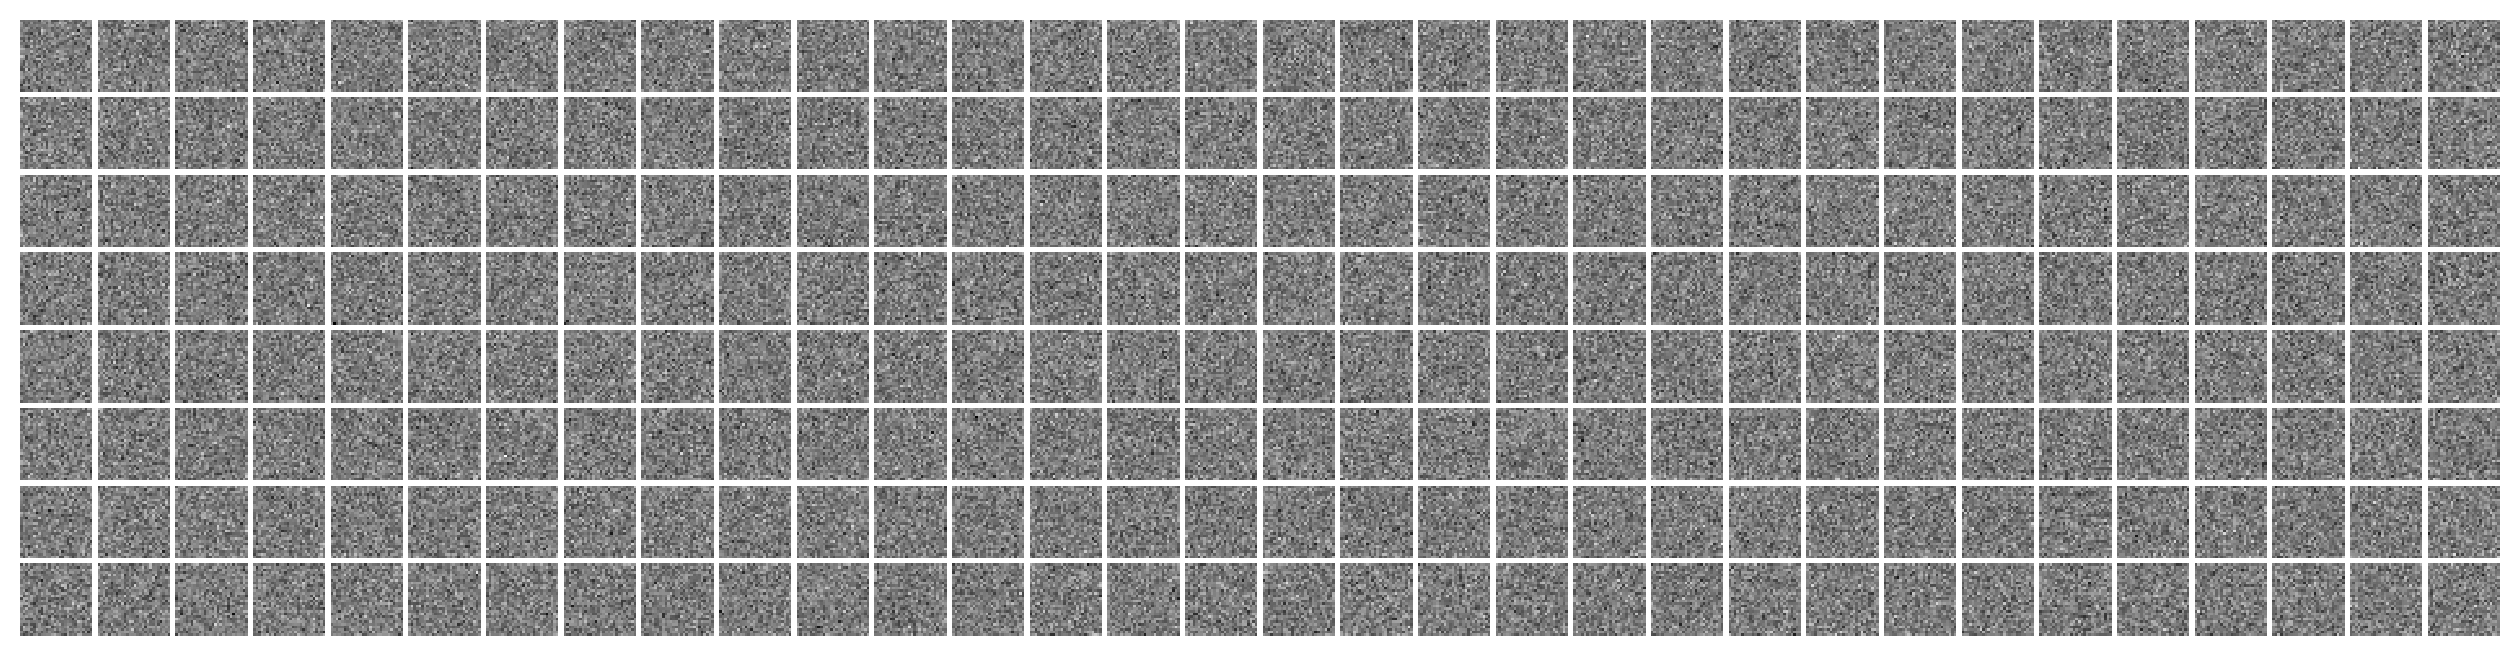

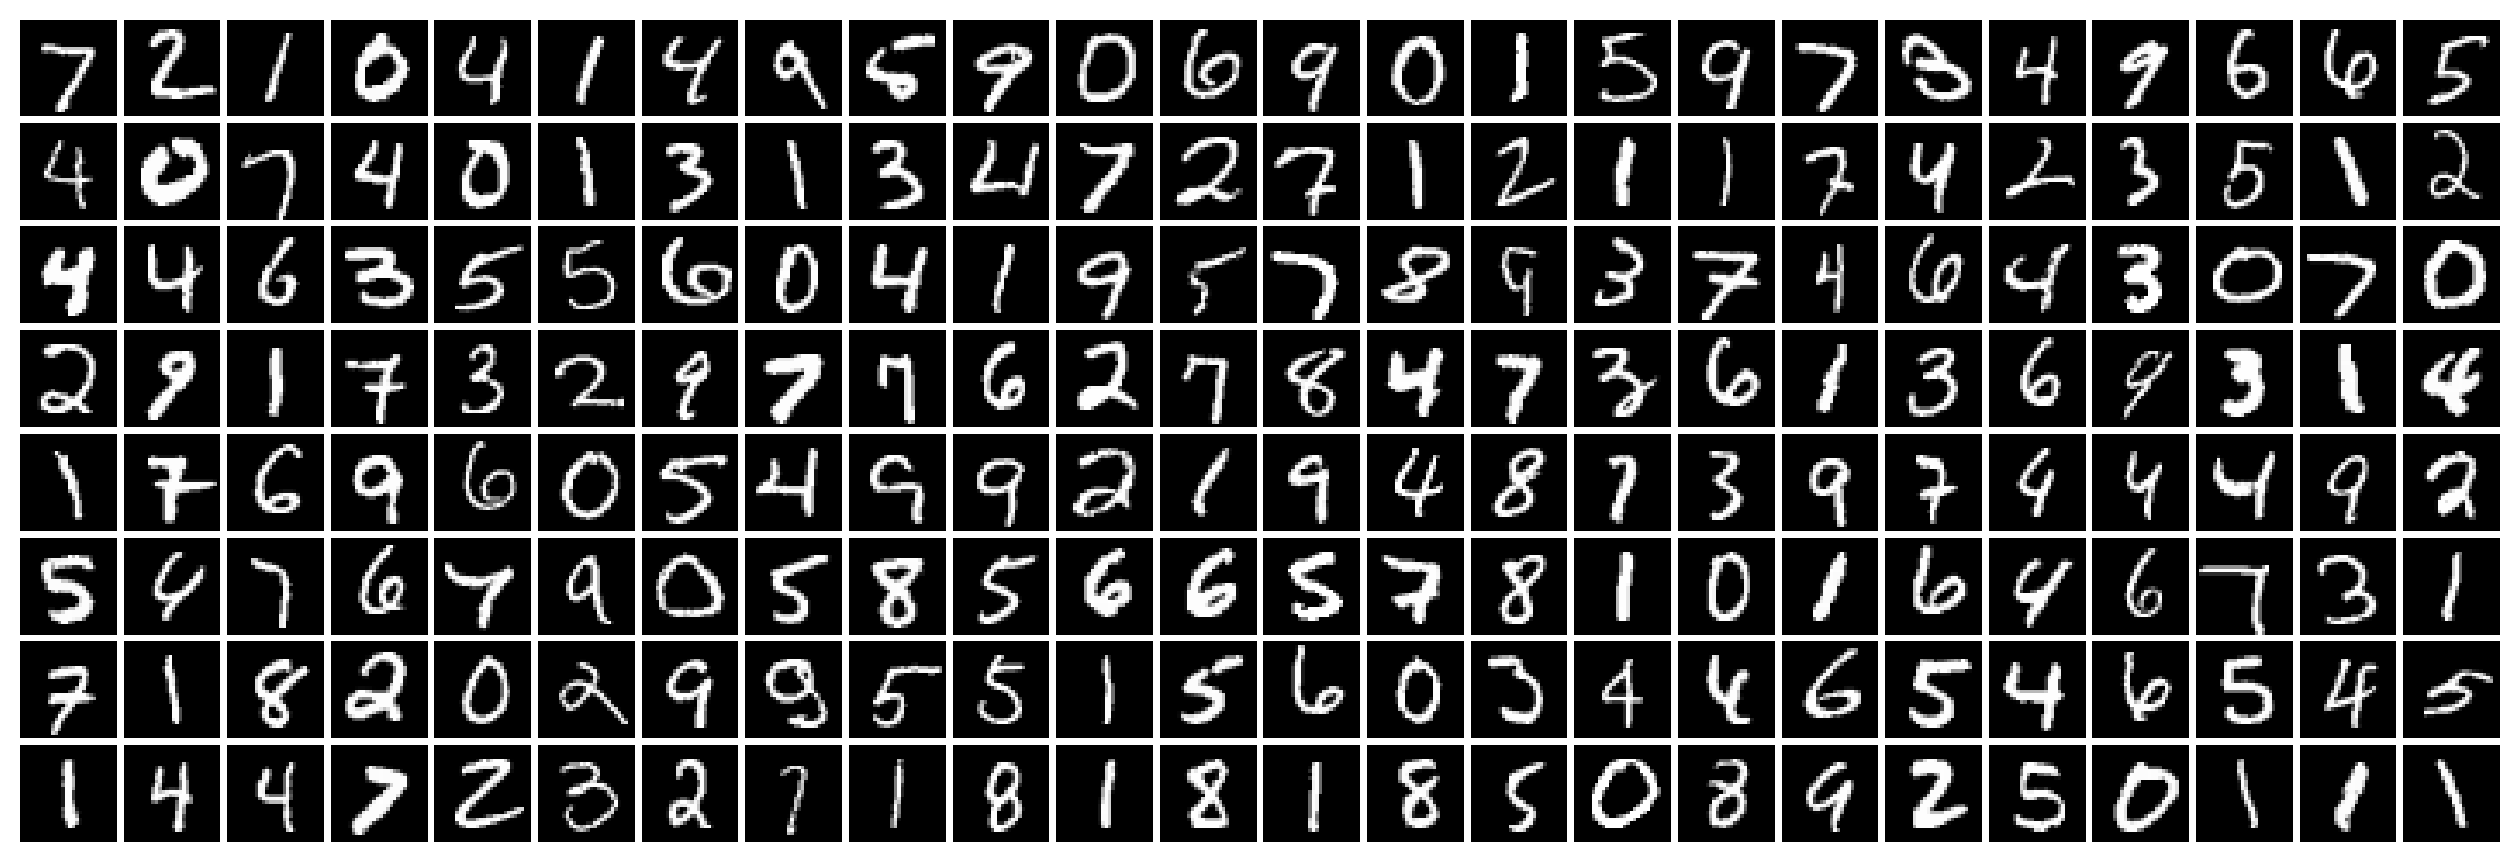

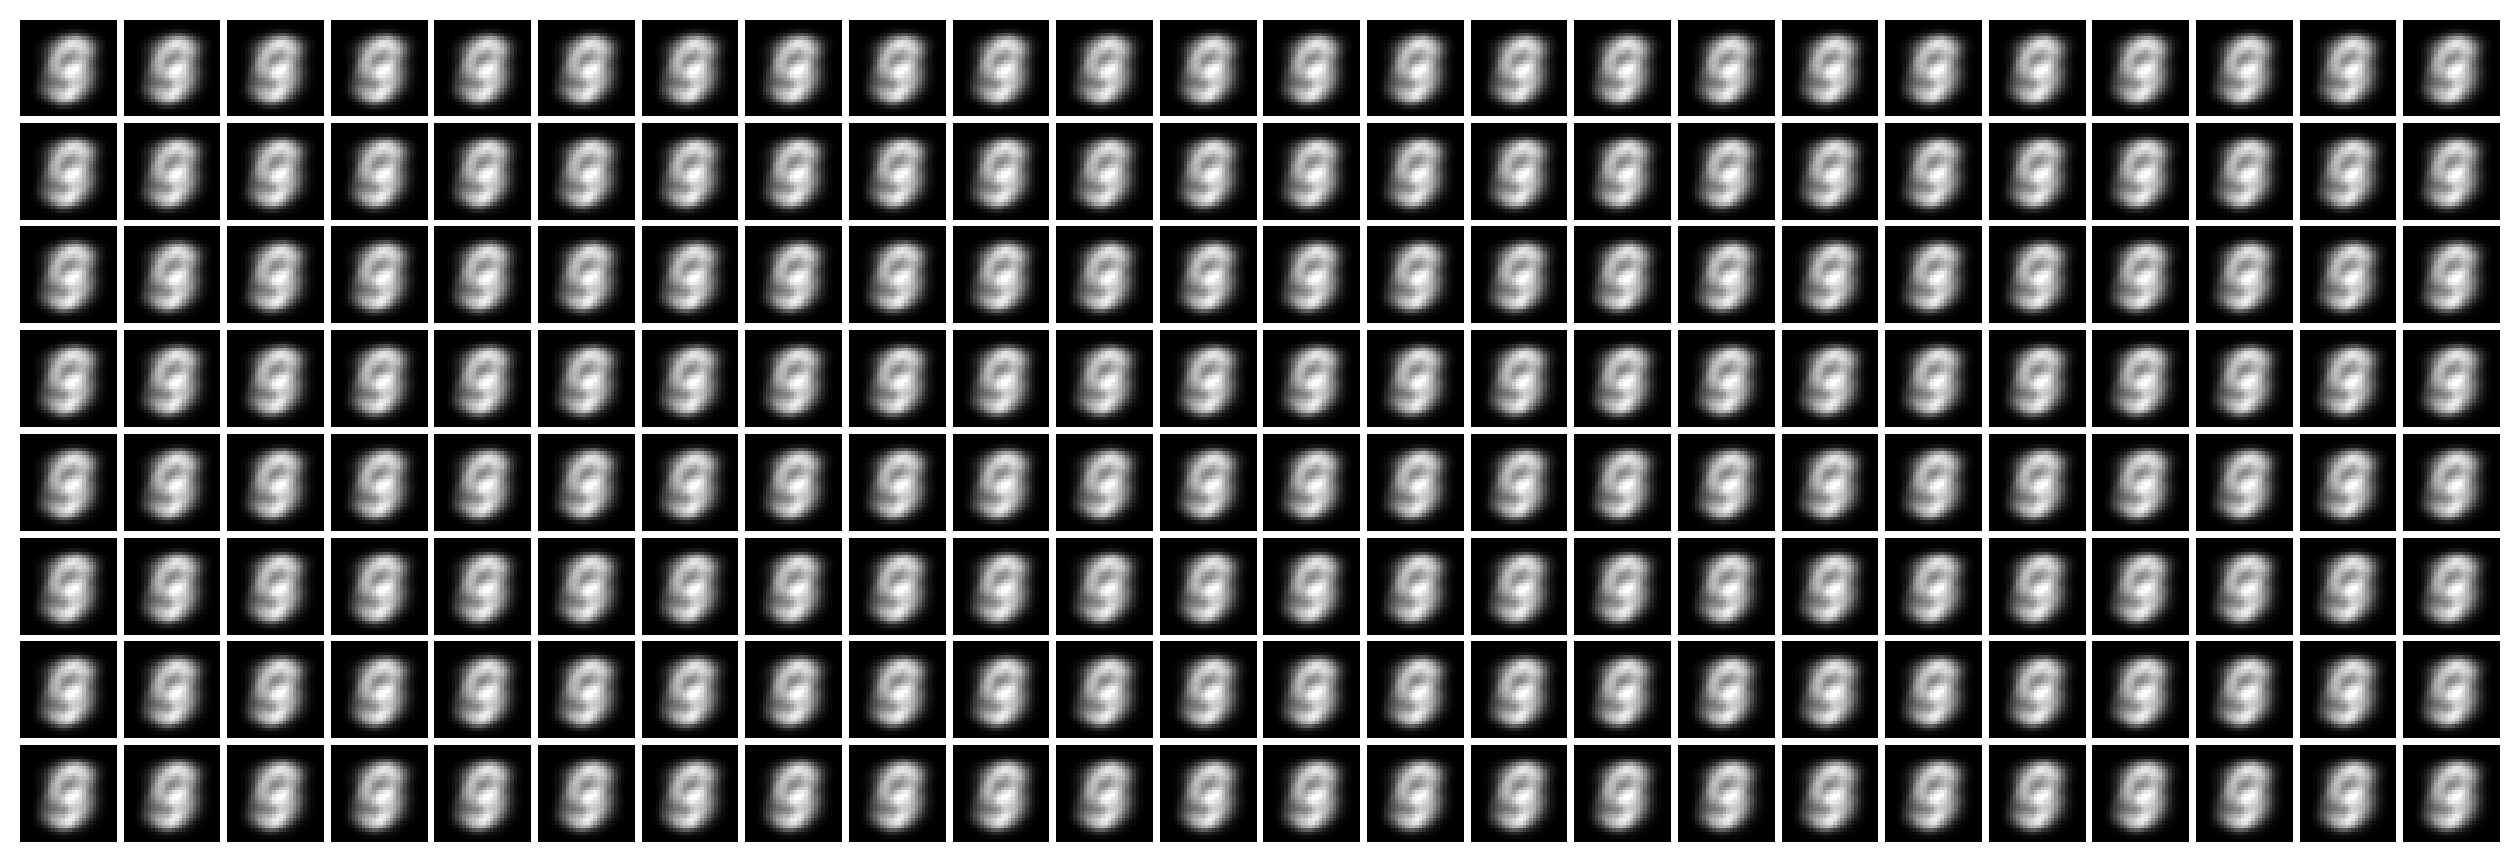


Learning layer 0
Epoch 0:	########################################	elapsed: 0.62s, reconstruction error: 31.66
Epoch 1:	########################################	elapsed: 0.43s, reconstruction error: 24.76
Epoch 2:	########################################	elapsed: 0.82s, reconstruction error: 21.29
Epoch 3:	########################################	elapsed: 0.64s, reconstruction error: 19.00
Epoch 4:	########################################	elapsed: 0.43s, reconstruction error: 17.64
Epoch 5:	########################################	elapsed: 0.55s, reconstruction error: 15.24
Epoch 6:	########################################	elapsed: 0.60s, reconstruction error: 13.77
Epoch 7:	########################################	elapsed: 0.52s, reconstruction error: 12.63
Epoch 8:	########################################	elapsed: 0.51s, reconstruction error: 12.05
Epoch 9:	########################################	elapsed: 0.50s, reconstruction error: 11.58
Epoch 10:	################################

Reconstruction cost before finetuning: 142.19

Epoch 1:	########################################	elapsed: 1.75s, cross-entropy: 109.48
Epoch 2:	########################################	elapsed: 1.98s, cross-entropy: 105.38
Epoch 3:	########################################	elapsed: 1.84s, cross-entropy: 103.01
Epoch 4:	########################################	elapsed: 1.91s, cross-entropy: 101.30
Epoch 5:	########################################	elapsed: 1.92s, cross-entropy: 99.99
Epoch 6:	########################################	elapsed: 1.60s, cross-entropy: 98.94
Epoch 7:	########################################	elapsed: 1.69s, cross-entropy: 98.06
Epoch 8:	########################################	elapsed: 2.09s, cross-entropy: 97.31
Epoch 9:	########################################	elapsed: 1.79s, cross-entropy: 96.65
Epoch 10:	########################################	elapsed: 1.81s, cross-entropy: 96.07
Epoch 11:	########################################	elapsed: 1.85s, cross-entro

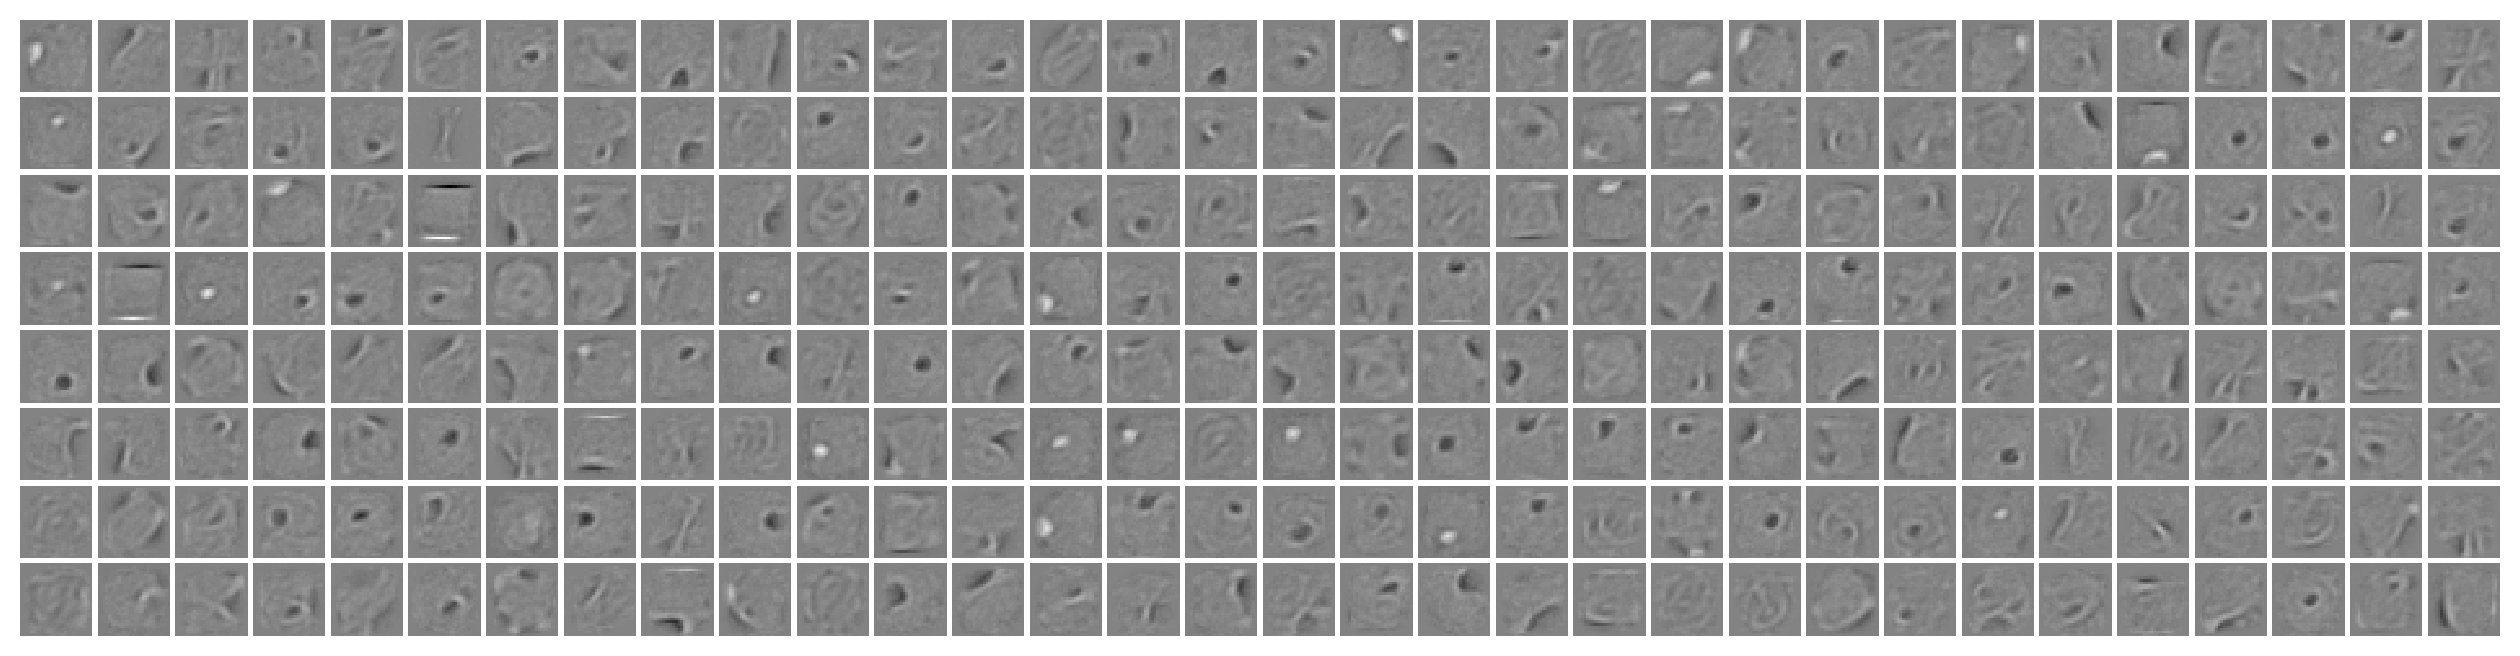

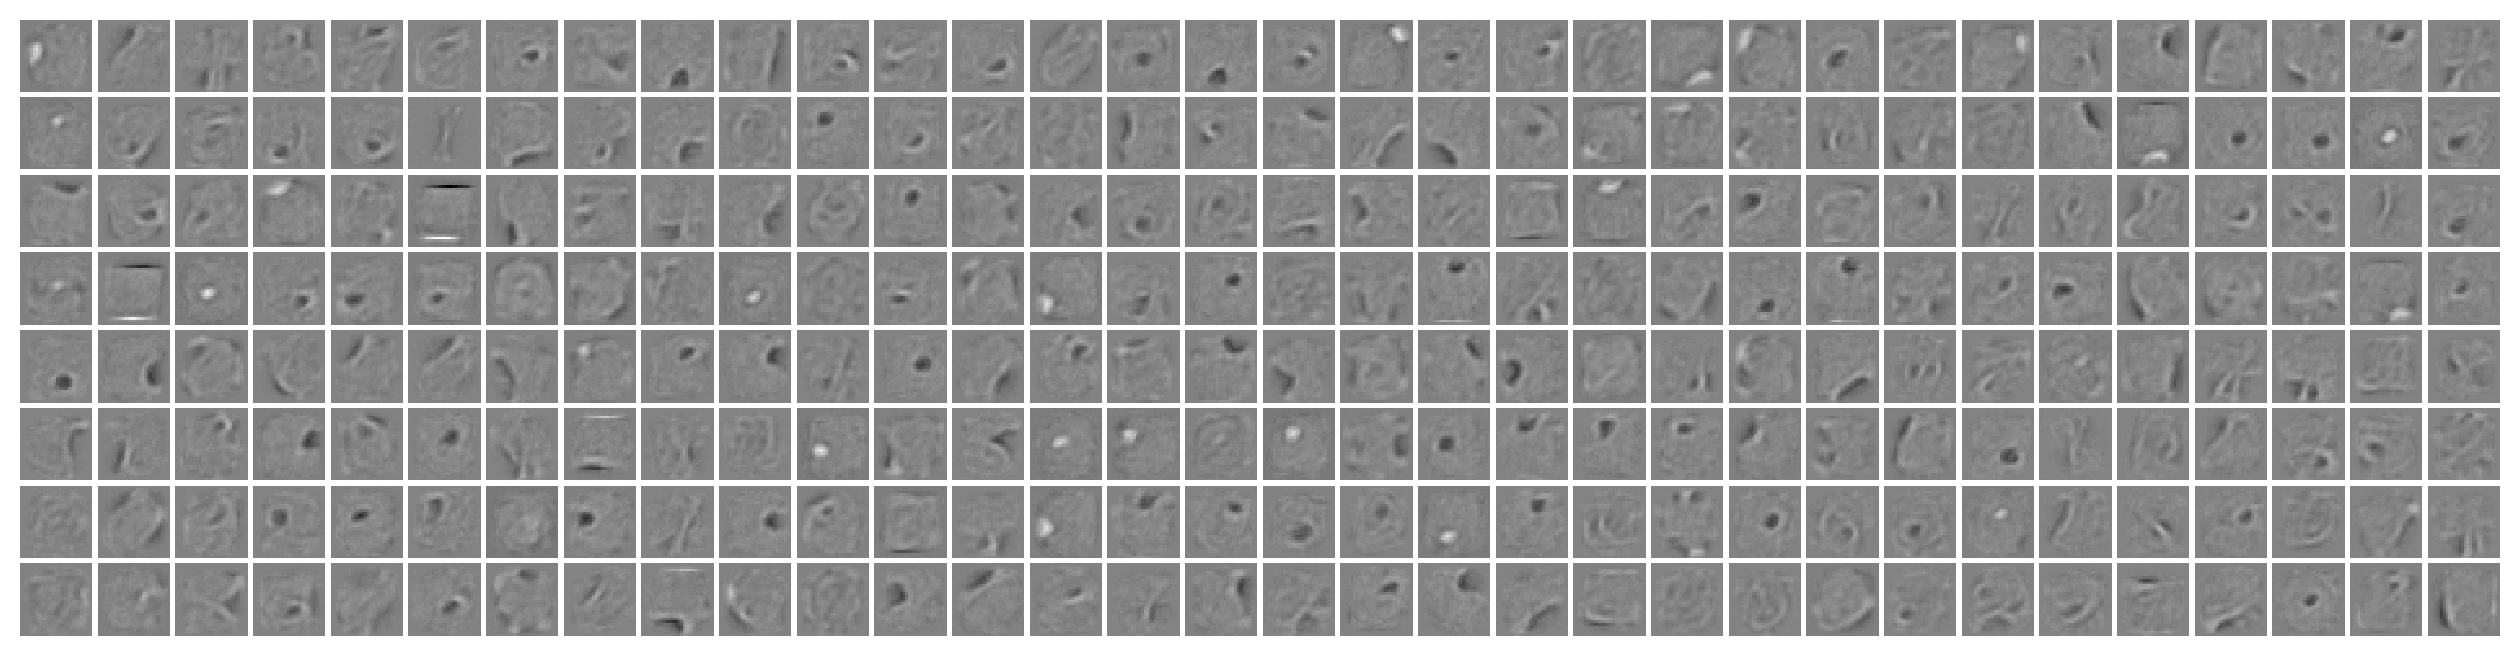

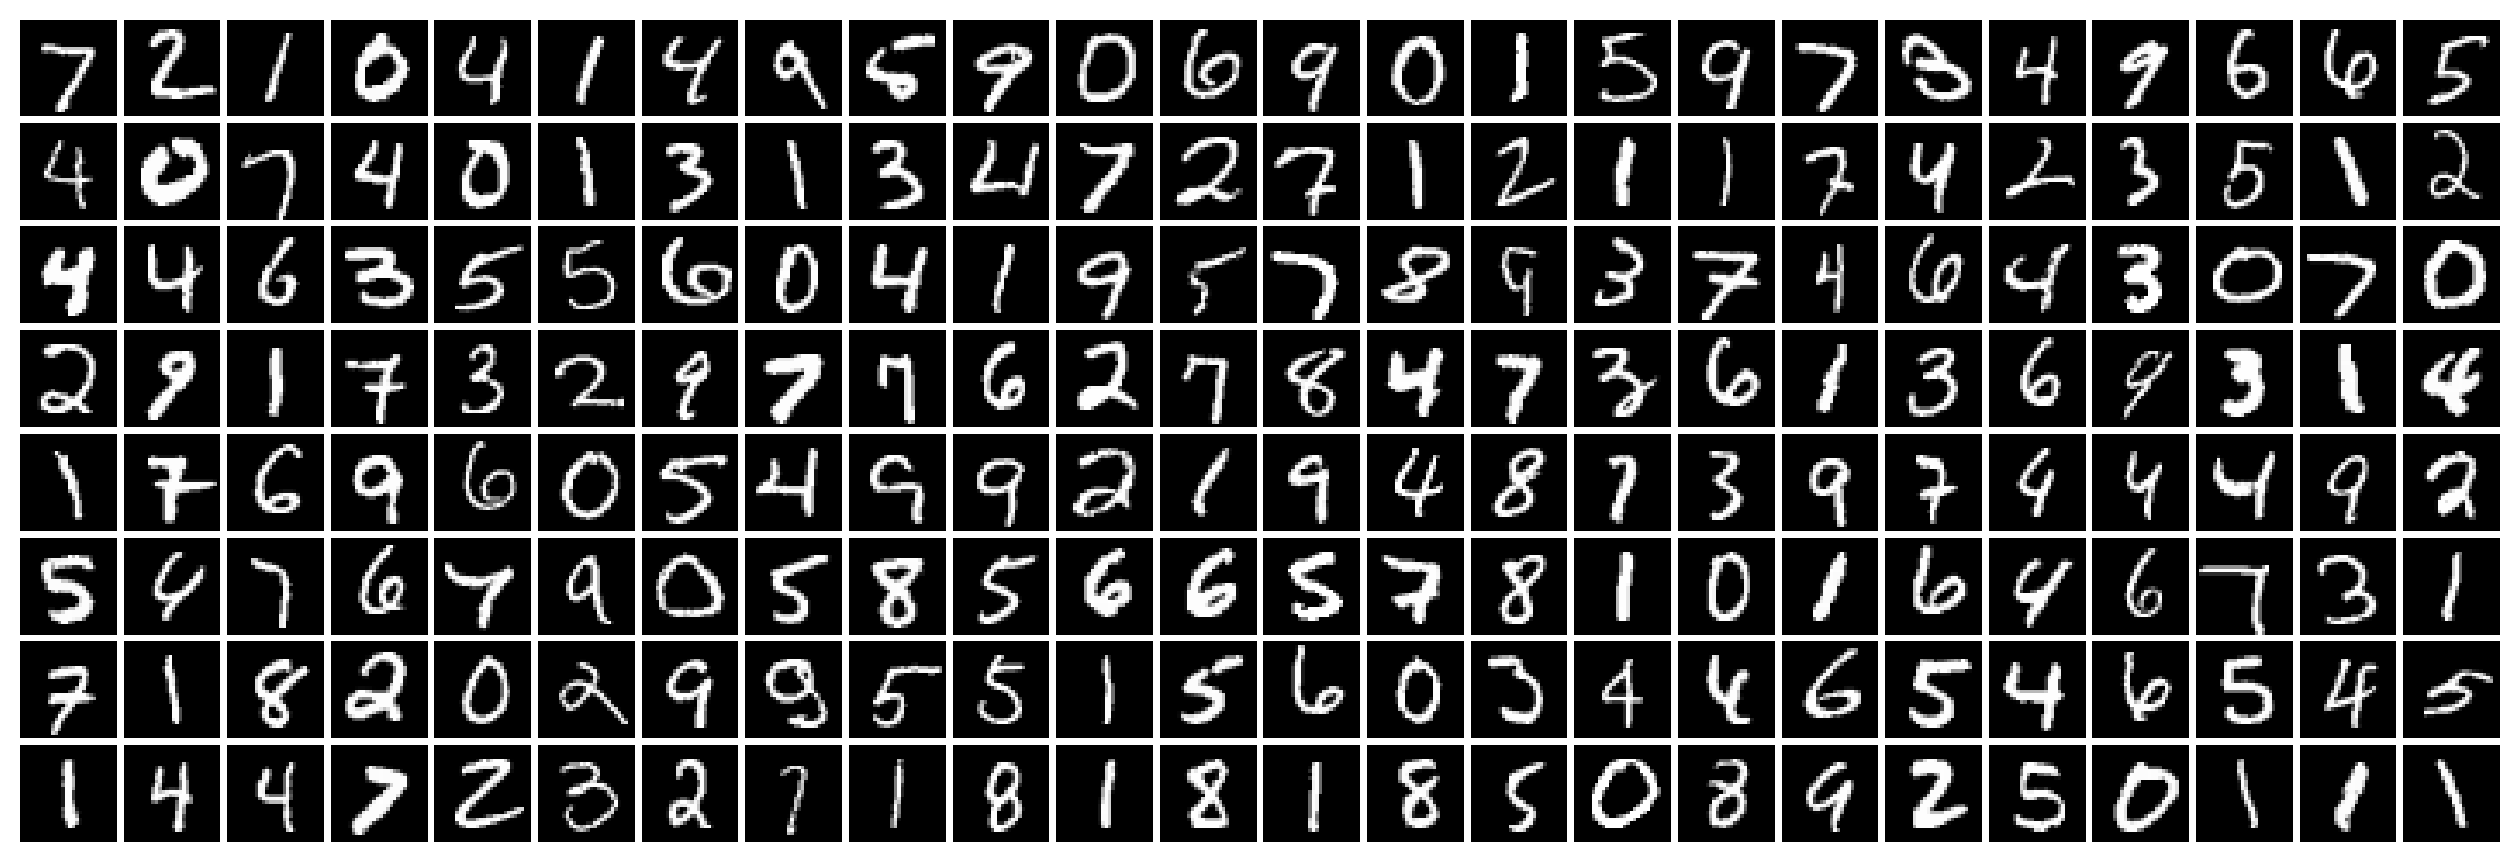

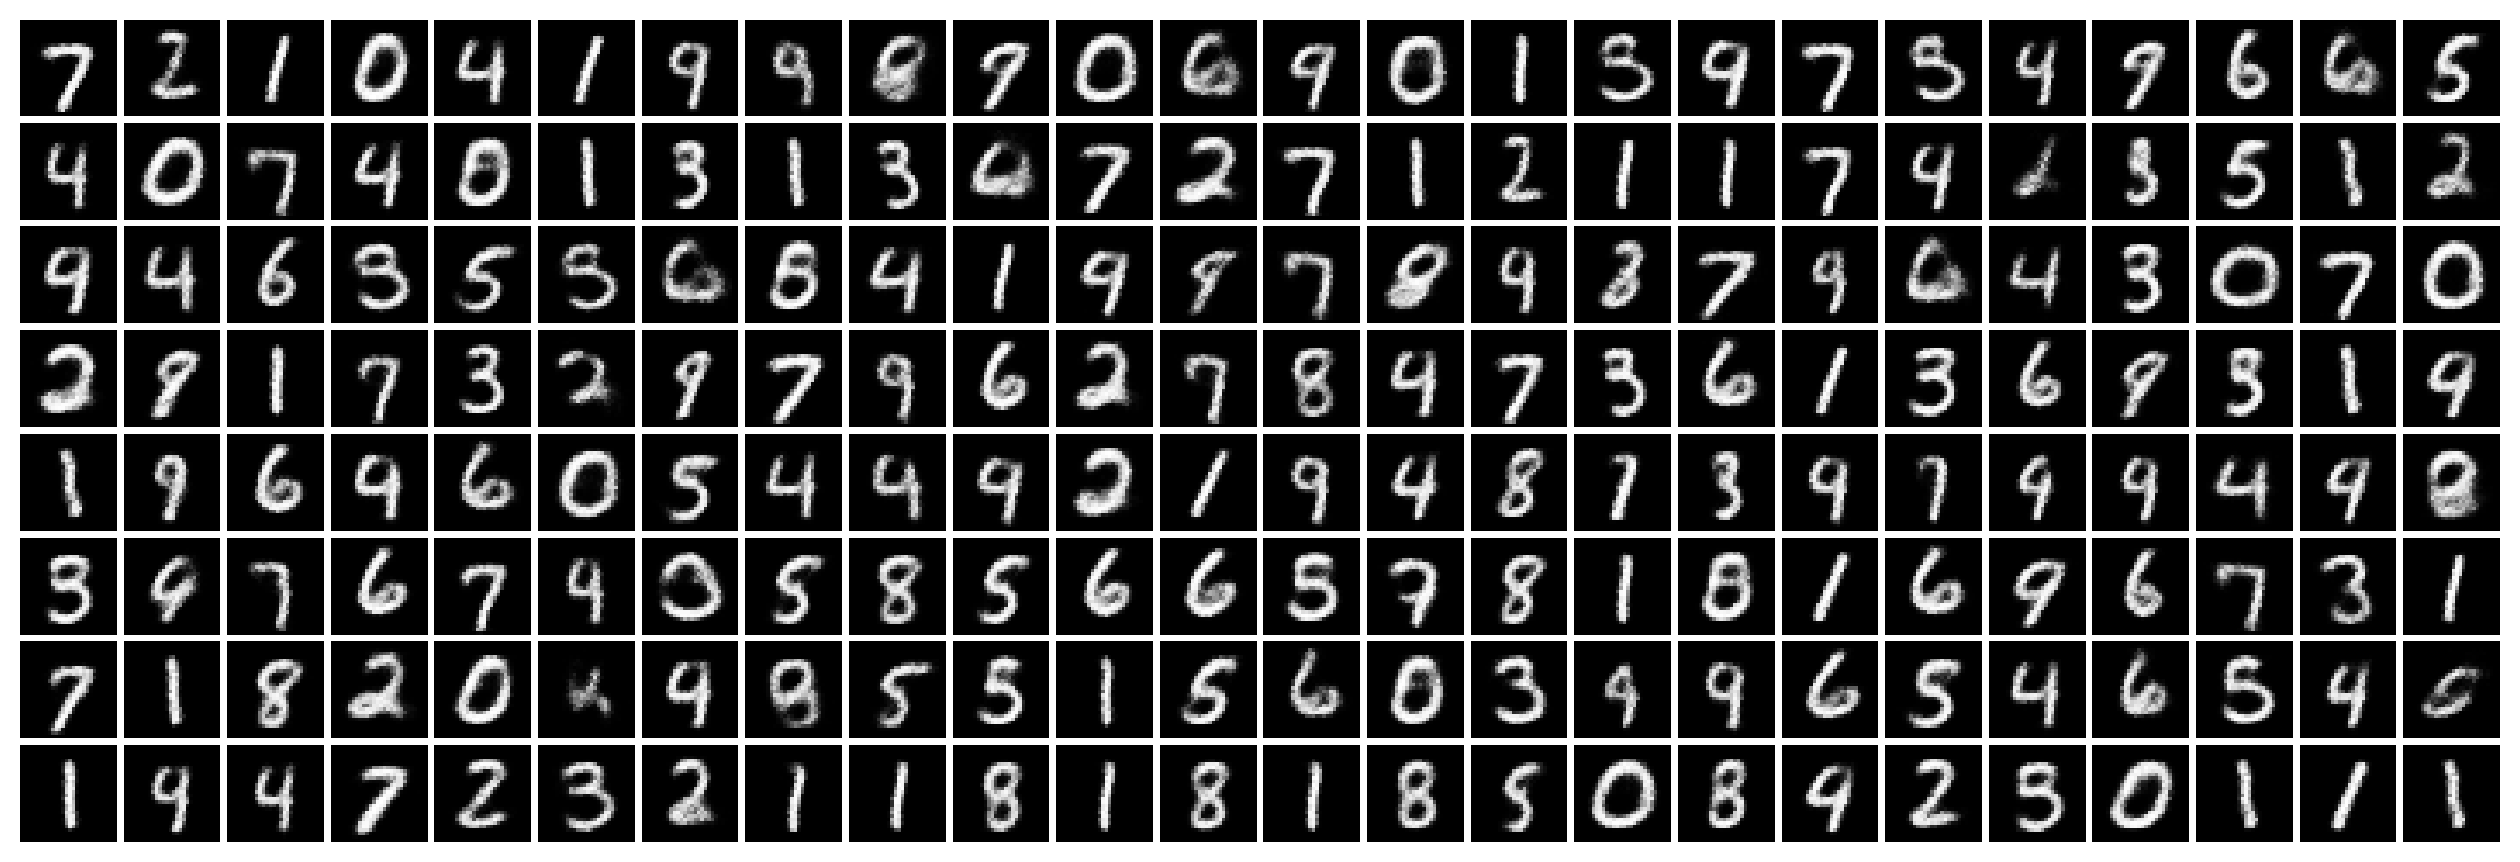

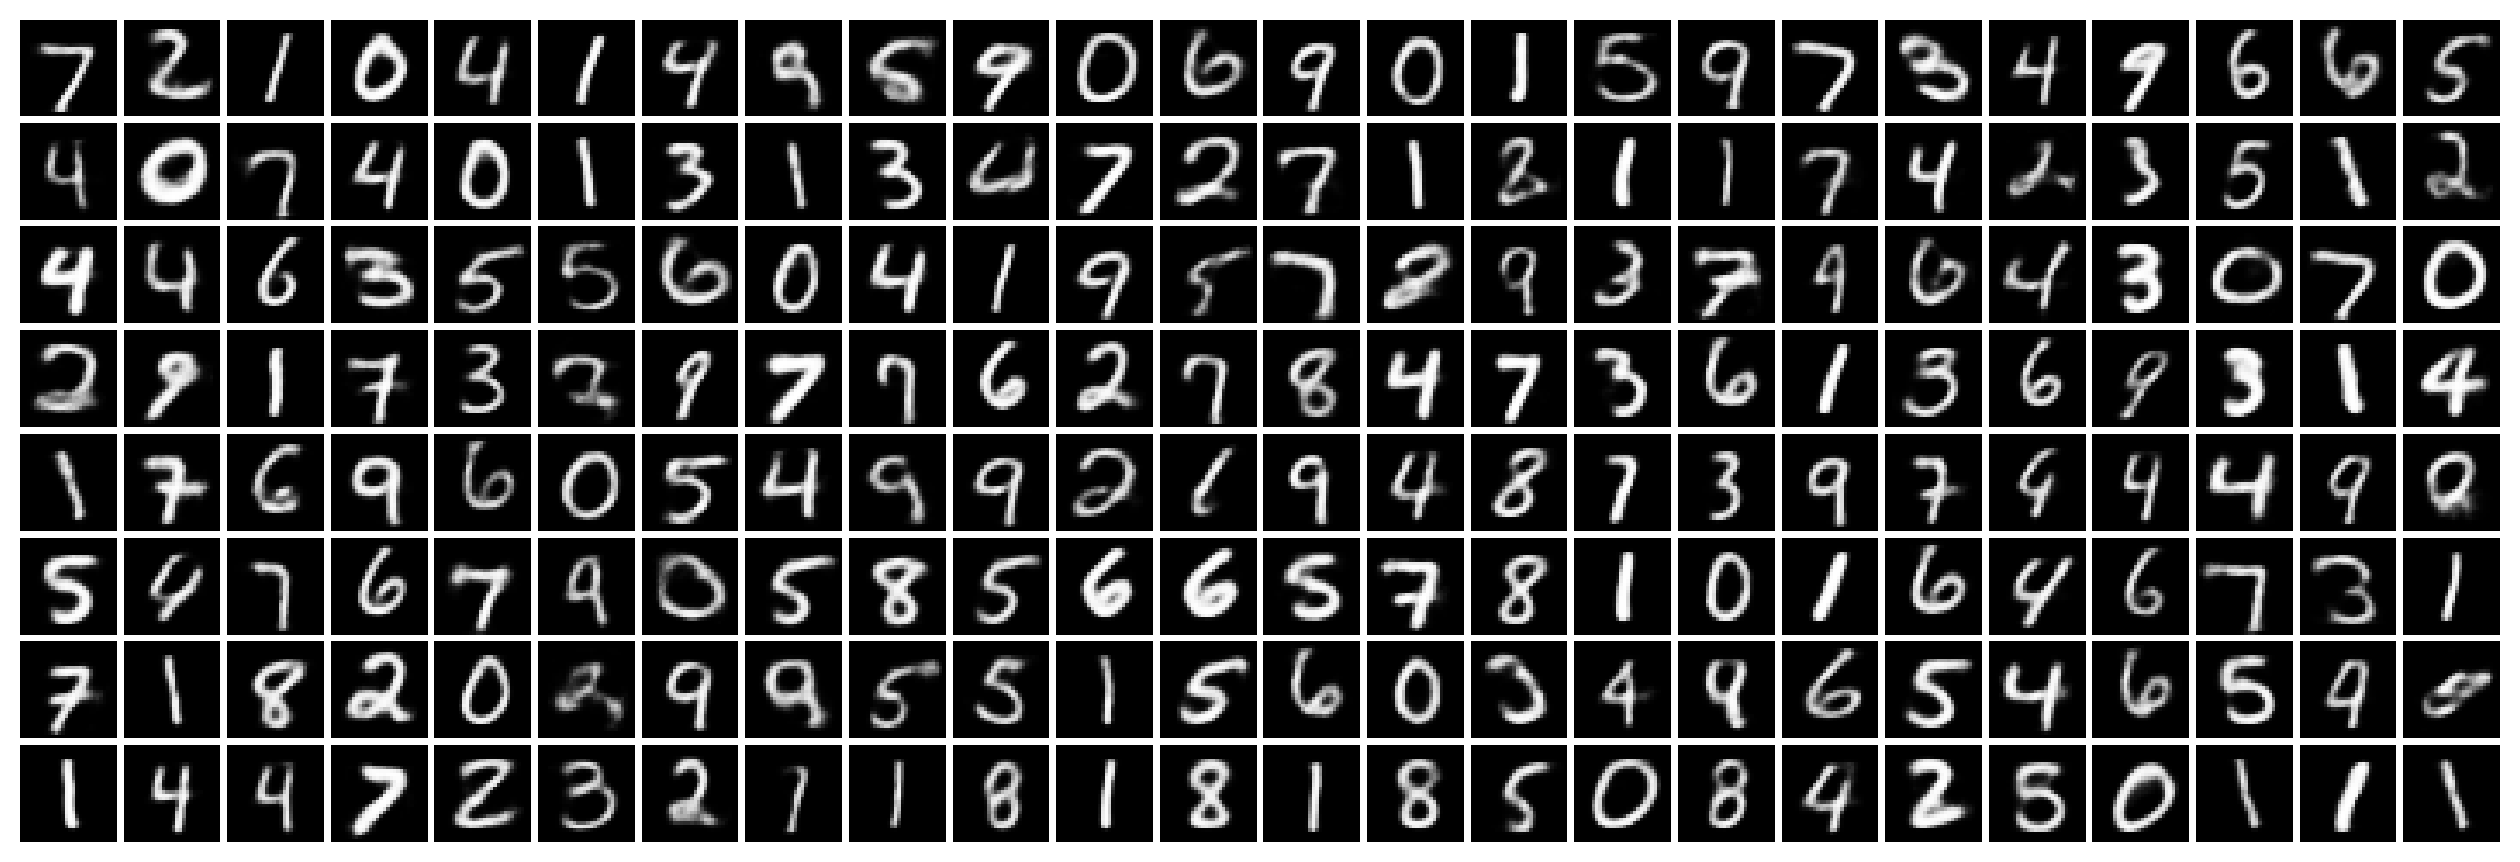

In [20]:
dbn = [
    RestrictedBoltzmannMachine(
        VISIBLE_LAYER_SIZE, 256, sigmoid, sigmoid, RBM_LEARNING_RATE, 0.5, L2_PENALTY
    ),
    RestrictedBoltzmannMachine(
        256, 128, sigmoid, sigmoid, RBM_LEARNING_RATE, 0.5, L2_PENALTY
    ),
    RestrictedBoltzmannMachine(
        128, 64, sigmoid, sigmoid, RBM_LEARNING_RATE, 0.5, L2_PENALTY
    ),
    RestrictedBoltzmannMachine(
        64, 10, sigmoid, gaussian, RBM_LEARNING_RATE / 10.0, 0.5, L2_PENALTY
    ),
]


ae: MLP = [
    # encoder
    Layer(VISIBLE_LAYER_SIZE, 256, sigmoid,  sigmoid_derivative,  AE_LEARNING_RATE, AE_MOMENTUM, L2_PENALTY),
    Layer(256, 128,            sigmoid,  sigmoid_derivative,  AE_LEARNING_RATE, AE_MOMENTUM, L2_PENALTY),
    Layer(128, 64,             sigmoid,  sigmoid_derivative,  AE_LEARNING_RATE, AE_MOMENTUM, L2_PENALTY),
    Layer(64, 10,              gaussian, gaussian_derivative, AE_LEARNING_RATE / 10.0, AE_MOMENTUM, L2_PENALTY),
    # decoder (mirrored)
    Layer(10, 64,              sigmoid,  sigmoid_derivative,  AE_LEARNING_RATE / 10.0, AE_MOMENTUM, L2_PENALTY),
    Layer(64, 128,             sigmoid,  sigmoid_derivative,  AE_LEARNING_RATE, AE_MOMENTUM, L2_PENALTY),
    Layer(128, 256,            sigmoid,  sigmoid_derivative,  AE_LEARNING_RATE, AE_MOMENTUM, L2_PENALTY),
    Layer(256, VISIBLE_LAYER_SIZE, sigmoid, sigmoid_derivative, AE_LEARNING_RATE, AE_MOMENTUM, L2_PENALTY),
]

compare_results(
    ae=ae,
    dbn=dbn,
    train_set=mnist_train_images,
    validation_set=mnist_test_images,
    monitoring_set=monitoring_set,
    batch_size=BATCH_SIZE,
    epochs_count=EPOCHS_COUNT,
)

## Additional materials
* [Medium | Why do we use cross entropy in logistic regresion? A statistical view | Likelihood & log-likelihood](https://medium.com/@haythamahmed2001/why-do-we-use-cross-entropy-in-logistic-regression-a-statistical-view-4414ea95c72b)